In [1]:
!pip install langgraph


In [2]:
!pip install langchain

In [3]:
!pip install google-generativeai

In [4]:
!pip install langchain-google-genai

In [5]:
!pip install dotenv

In [6]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict

In [7]:
load_dotenv()

True

In [8]:
model= ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)


In [9]:
# create a state

class LLMState(TypedDict):

  question:str
  answer:str

In [10]:
def llm_qa(state:LLMState)->LLMState:

  # extract the question from state

  question=state['question']

  # form a prompt

  prompt=f'Answer the following question{question}'

  # ask that question to the LLM

  answer=model.invoke(prompt).content

  # update the answer in the state
  state['answer']=answer

  return state



In [11]:
# create a graph

graph=StateGraph(LLMState)

# add nodes

graph.add_node('llm_qa',llm_qa)

# Add edges
graph.add_edge(START,'llm_qa')
graph.add_edge('llm_qa',END)

# compile
workflow=graph.compile()




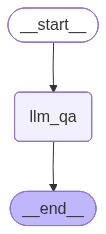

In [12]:
workflow

In [13]:
# execute

initial_state={'question':'how far is the moon from the earth'}

final_state=workflow.invoke(initial_state)
print(final_state)

{'question': 'how far is the moon from the earth', 'answer': "The distance between the Earth and the Moon is not constant because the Moon's orbit around Earth is elliptical, not a perfect circle.\n\nHere are the key figures:\n\n*   **Average Distance:** Approximately **384,400 kilometers (238,900 miles)**\n*   **Perigee (closest point):** Approximately **363,104 kilometers (225,622 miles)**\n*   **Apogee (farthest point):** Approximately **405,696 kilometers (252,088 miles)**\n\nSo, while the average is a good general number, the actual distance varies throughout the lunar month."}
